# NFL 4th Down — League Evolution (1999–2025)
Has the NFL gotten smarter on 4th down? This notebook tracks how decision-making
has evolved over 26 seasons, when the analytics revolution shows up in the data,
and which franchises led the shift.

**Inputs:** `data/fourth_downs_graded.parquet`  
**Outputs:** four charts in `outputs/figures/`, `outputs/league_trends.csv`

In [1]:
import sys
sys.path.append('../src')

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

DATA_DIR = '../data/'
SAVE_DIR = '../outputs/figures/'
OUT_DIR  = '../outputs/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)

# Era definitions — used consistently across all charts
ERAS = [
    ('Traditional', 1999, 2018, '#CFD8DC'),
    ('Analytics',   2019, 2025, '#90A4AE'),
]
ERA_COLORS = {'Traditional': '#546E7A', 'Analytics': '#2E7D32'}

GO_COLOR      = '#2E7D32'
PUNT_COLOR    = '#7B1FA2'
FG_COLOR      = '#1565C0'
NEUTRAL_COLOR = '#546E7A'

## 1. Load Data

In [2]:
df = pd.read_parquet(DATA_DIR + 'fourth_downs_graded.parquet')
print(f'Full dataset: {len(df):,} plays, {df["season"].min()}–{df["season"].max()}')
print(f'Seasons: {df["season"].nunique()}')
print(f'Graded plays (decision_gap not null): {df["decision_gap"].notna().sum():,} ({df["decision_gap"].notna().mean()*100:.1f}%)')
print(f'Teams: {df["posteam"].nunique()}')

Full dataset: 107,189 plays, 1999–2025
Seasons: 27
Graded plays (decision_gap not null): 105,544 (98.5%)
Teams: 32


## 2. Season-by-Season Stats

In [3]:
graded = df.dropna(subset=['decision_gap'])

by_season = (
    graded
    .groupby('season')
    .agg(
        n_decisions   = ('decision_gap', 'count'),
        go_rate       = ('decision',     lambda x: (x == 'go_for_it').mean()),
        punt_rate     = ('decision',     lambda x: (x == 'punt').mean()),
        fg_rate       = ('decision',     lambda x: (x == 'field_goal').mean()),
        mean_dqs      = ('decision_gap', 'mean'),
        std_dqs       = ('decision_gap', 'std'),
        mean_odr      = ('made_optimal', 'mean'),
        total_gap     = ('decision_gap', 'sum'),
    )
    .reset_index()
)

# Standard error for confidence band on DQS chart
by_season['se_dqs'] = by_season['std_dqs'] / np.sqrt(by_season['n_decisions'])

print('Season-by-Season Stats (first 5 and last 5):')
display_cols = ['season','n_decisions','go_rate','mean_dqs','mean_odr','total_gap']
print(
    pd.concat([by_season.head(5), by_season.tail(5)])
    [display_cols]
    .assign(
        go_rate   = lambda x: (x['go_rate']*100).map('{:.1f}%'.format),
        mean_dqs  = lambda x: x['mean_dqs'].map('{:.4f}'.format),
        mean_odr  = lambda x: (x['mean_odr']*100).map('{:.1f}%'.format),
        total_gap = lambda x: x['total_gap'].map('{:.2f}'.format),
    )
    .to_string(index=False)
)

Season-by-Season Stats (first 5 and last 5):
 season  n_decisions go_rate mean_dqs mean_odr total_gap
   1999         4047   11.2%   0.0092    65.1%     37.07
   2000         3872   11.6%   0.0098    62.8%     37.87
   2001         3945   11.6%   0.0095    63.4%     37.41
   2002         3912   12.4%   0.0095    63.5%     37.23
   2003         4008   12.4%   0.0094    63.4%     37.58
   2021         3912   19.8%   0.0075    69.4%     29.18
   2022         3990   17.9%   0.0077    71.6%     30.56
   2023         4159   18.9%   0.0070    72.6%     29.20
   2024         3920   19.3%   0.0075    70.7%     29.58
   2025         3887   22.0%   0.0066    73.1%     25.75


## 3. Era Analysis
Two eras: **Traditional** (1999–2018), **Analytics** (2019–2025)

In [4]:
def era_label(season):
    if season <= 2018: return 'Traditional'
    return 'Analytics'

graded = graded.copy()
graded['era'] = graded['season'].apply(era_label)

era_stats = (
    graded
    .groupby('era')
    .agg(
        n_decisions = ('decision_gap', 'count'),
        n_seasons   = ('season',       'nunique'),
        go_rate     = ('decision',     lambda x: (x == 'go_for_it').mean()),
        punt_rate   = ('decision',     lambda x: (x == 'punt').mean()),
        fg_rate     = ('decision',     lambda x: (x == 'field_goal').mean()),
        mean_dqs    = ('decision_gap', 'mean'),
        mean_odr    = ('made_optimal', 'mean'),
    )
    .reindex(['Traditional', 'Analytics'])
    .reset_index()
)

print('Era Breakdown:')
print(
    era_stats
    .assign(
        go_rate   = lambda x: (x['go_rate']*100).map('{:.1f}%'.format),
        punt_rate = lambda x: (x['punt_rate']*100).map('{:.1f}%'.format),
        fg_rate   = lambda x: (x['fg_rate']*100).map('{:.1f}%'.format),
        mean_dqs  = lambda x: x['mean_dqs'].map('{:.4f}'.format),
        mean_odr  = lambda x: (x['mean_odr']*100).map('{:.1f}%'.format),
    )
    .to_string(index=False)
)

# Change from Traditional to Analytics
traditional = era_stats[era_stats['era'] == 'Traditional'].iloc[0]
analytics  = era_stats[era_stats['era'] == 'Analytics'].iloc[0]
go_change  = (analytics['go_rate'] - traditional['go_rate']) * 100
dqs_change = (analytics['mean_dqs'] - traditional['mean_dqs']) * 100

print(f'\nTraditional → Analytics shift:')
print(f'  Go-for-it rate: {go_change:+.1f}pp')
print(f'  Mean DQS:       {dqs_change:+.4f} WPA pts ({"better" if dqs_change < 0 else "worse"})')

Era Breakdown:
       era  n_decisions  n_seasons go_rate punt_rate fg_rate mean_dqs mean_odr
   Classic        43198         11   12.3%     64.9%   22.9%   0.0092    64.5%
Transition        35209          9   12.1%     63.9%   24.1%   0.0085    67.0%
 Analytics        27137          7   18.8%     55.8%   25.3%   0.0073    70.9%

Classic → Analytics shift:
  Go-for-it rate: +6.6pp
  Mean DQS:       -0.1915 WPA pts (better)


## 4. Early Adopter Franchises
Which teams shifted their 4th down aggression the most from the Traditional to Analytics era?

In [5]:
team_era = (
    graded
    .groupby(['posteam', 'era'])
    .agg(go_rate = ('decision', lambda x: (x == 'go_for_it').mean()),
         n       = ('decision_gap', 'count'))
    .reset_index()
)

# Pivot to wide: one row per team, columns = era go_rate
team_pivot = team_era.pivot(index='posteam', columns='era', values='go_rate').dropna()
team_pivot['shift'] = team_pivot['Analytics'] - team_pivot['Traditional']
team_pivot = team_pivot.sort_values('shift', ascending=False)

print('Top 10 teams with largest go-rate increase (Traditional → Analytics):')
print(
    team_pivot.head(10)[['Traditional','Analytics','shift']]
    .mul(100).round(1)
    .to_string()
)

print('\nBottom 10 teams (most conservative shift or decrease):')
print(
    team_pivot.tail(10)[['Traditional','Analytics','shift']]
    .mul(100).round(1)
    .to_string()
)

Top 10 teams with largest go-rate increase (Classic → Analytics):
era      Classic  Transition  Analytics  shift
posteam                                       
CAR          9.8        11.4       24.2   14.4
PHI          8.9        15.1       21.9   13.0
IND         11.1        10.6       22.0   10.9
CLE         11.5        14.0       22.4   10.9
NYG         12.0        11.9       22.8   10.8
DET         14.1        11.8       24.6   10.5
CHI         13.5        11.8       22.8    9.3
GB          10.6        13.6       19.9    9.3
LAC          9.8         9.6       19.1    9.3
ARI         12.9        10.4       21.9    9.0

Bottom 10 teams (most conservative shift or decrease):
era      Classic  Transition  Analytics  shift
posteam                                       
CIN         13.1        12.0       16.6    3.5
KC          12.7        11.9       16.2    3.4
HOU         12.6        11.5       15.6    3.0
SF          13.0        11.5       15.4    2.4
LA          14.5        12.2    

## 5. Chart — League Go-For-It Rate Trend (1999–2025)
The headline chart for the article's opening section. Era shading shows when the shift happened.

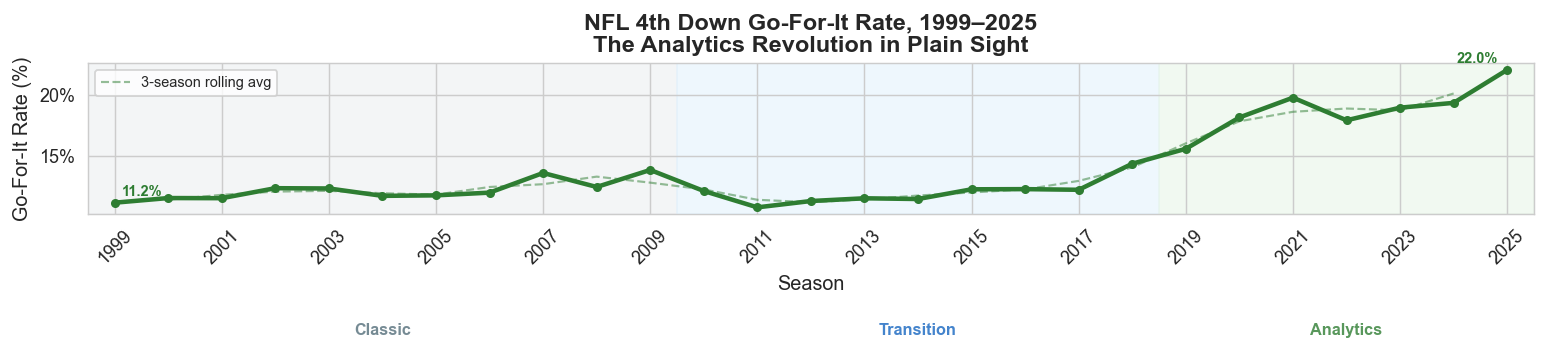

Saved: 12_league_goforit_trend.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

seasons = by_season['season'].values

# Era background shading
era_bg = [
    ('Traditional', 1999, 2018, '#ECEFF1'),
    ('Analytics',   2019, 2025, '#E8F5E9'),
]
era_label_colors = {'Traditional': '#546E7A', 'Analytics': '#2E7D32'}

for era_name, y_start, y_end, color in era_bg:
    ax.axvspan(y_start - 0.5, y_end + 0.5, color=color, alpha=0.6, zorder=0)
    ax.text(
        (y_start + y_end) / 2, 0.215,
        era_name, ha='center', va='bottom', fontsize=9,
        color=era_label_colors[era_name], fontweight='bold', alpha=0.8
    )

# Go-for-it rate line
ax.plot(seasons, by_season['go_rate'] * 100, color=GO_COLOR,
        linewidth=2.5, marker='o', markersize=4, zorder=3)

# Rolling 3-season average smoothing line
go_smooth = by_season['go_rate'].rolling(3, center=True).mean() * 100
ax.plot(seasons, go_smooth, color=GO_COLOR, linewidth=1.2,
        linestyle='--', alpha=0.5, label='3-season rolling avg', zorder=2)

# Annotate first and last values
ax.annotate(
    f"{by_season['go_rate'].iloc[0]*100:.1f}%",
    xy=(seasons[0], by_season['go_rate'].iloc[0]*100),
    xytext=(4, 4), textcoords='offset points', fontsize=8, color=GO_COLOR, fontweight='bold'
)
ax.annotate(
    f"{by_season['go_rate'].iloc[-1]*100:.1f}%",
    xy=(seasons[-1], by_season['go_rate'].iloc[-1]*100),
    xytext=(-28, 4), textcoords='offset points', fontsize=8, color=GO_COLOR, fontweight='bold'
)

ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Go-For-It Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_xlim(1998.5, 2025.5)
ax.set_xticks(range(1999, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, loc='upper left')
ax.set_title(
    'NFL 4th Down Go-For-It Rate, 1999–2025\nThe Analytics Revolution in Plain Sight',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '12_league_goforit_trend.png', bbox_inches='tight')
plt.show()
print('Saved: 12_league_goforit_trend.png')

## 6. Chart — Are Coaches Getting Better? (DQS by Season)
A declining DQS over time means coaches are collectively getting closer to optimal decisions.

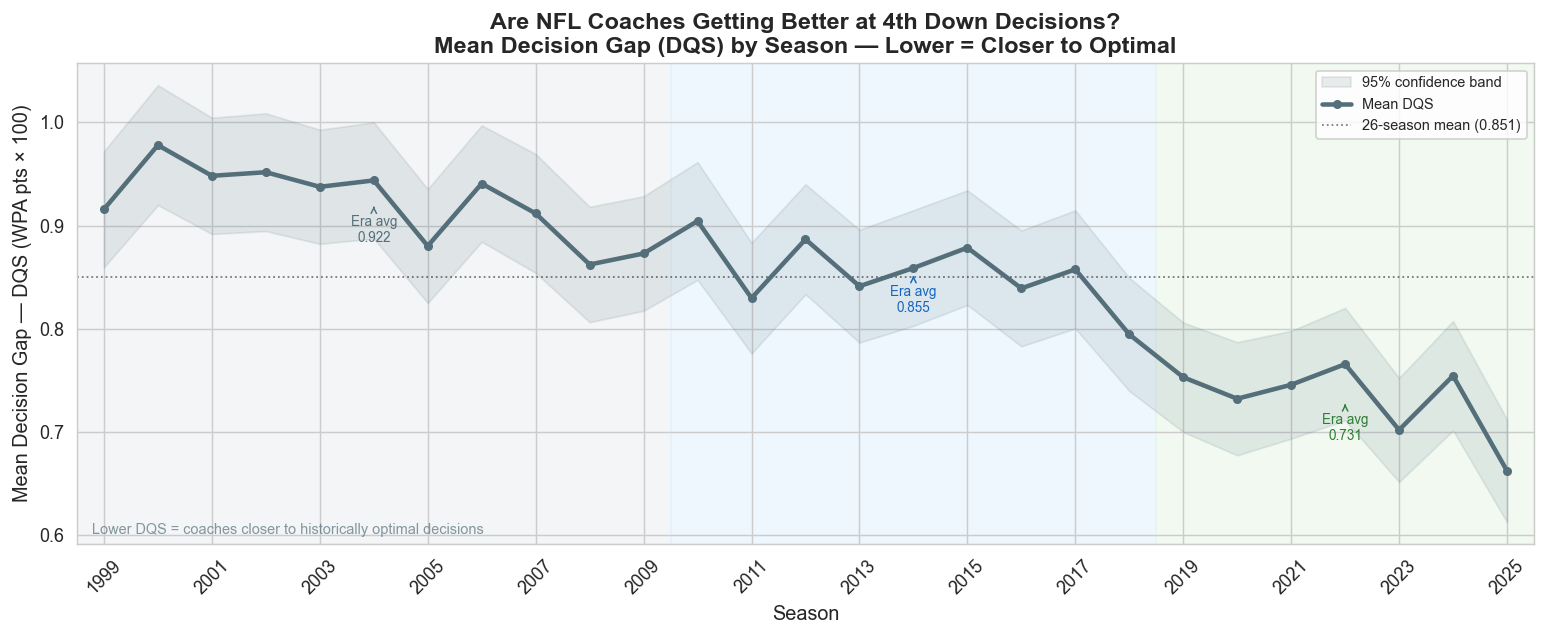

Saved: 13_league_dqs_by_season.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

# Era shading
for era_name, y_start, y_end, color in era_bg:
    ax.axvspan(y_start - 0.5, y_end + 0.5, color=color, alpha=0.6, zorder=0)

# 95% confidence band (mean ± 2*SE)
ax.fill_between(
    seasons,
    (by_season['mean_dqs'] - 2 * by_season['se_dqs']) * 100,
    (by_season['mean_dqs'] + 2 * by_season['se_dqs']) * 100,
    color=NEUTRAL_COLOR, alpha=0.12, label='95% confidence band'
)

# DQS line
ax.plot(seasons, by_season['mean_dqs'] * 100, color=NEUTRAL_COLOR,
        linewidth=2.5, marker='o', markersize=4, zorder=3, label='Mean DQS')

# Overall mean reference line
overall_mean = graded['decision_gap'].mean() * 100
ax.axhline(overall_mean, color='black', linewidth=1, linestyle=':', alpha=0.5,
           label=f'26-season mean ({overall_mean:.3f})')

# Annotate era averages
for era_name, y_start, y_end, _ in era_bg:
    era_mean = graded[graded['era'] == era_name]['decision_gap'].mean() * 100
    mid = (y_start + y_end) / 2
    ax.annotate(
        f'Era avg\n{era_mean:.3f}',
        xy=(mid, era_mean), xytext=(0, -22),
        textcoords='offset points', ha='center', fontsize=7.5,
        color=era_label_colors[era_name],
        arrowprops=dict(arrowstyle='->', color=era_label_colors[era_name], lw=0.8)
    )

ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Mean Decision Gap — DQS (WPA pts × 100)', fontsize=11)
ax.set_xlim(1998.5, 2025.5)
ax.set_xticks(range(1999, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, loc='upper right')
ax.set_title(
    'Are NFL Coaches Getting Better at 4th Down Decisions?\nMean Decision Gap (DQS) by Season — Lower = Closer to Optimal',
    fontsize=13, fontweight='bold'
)
ax.text(0.01, 0.02, 'Lower DQS = coaches closer to historically optimal decisions',
        transform=ax.transAxes, fontsize=8, color=NEUTRAL_COLOR, alpha=0.7)

plt.tight_layout()
plt.savefig(SAVE_DIR + '13_league_dqs_by_season.png', bbox_inches='tight')
plt.show()
print('Saved: 13_league_dqs_by_season.png')

## 7. Chart — Era Comparison
Side-by-side bars showing how go-for-it rate, ODR, and DQS changed across all three eras.

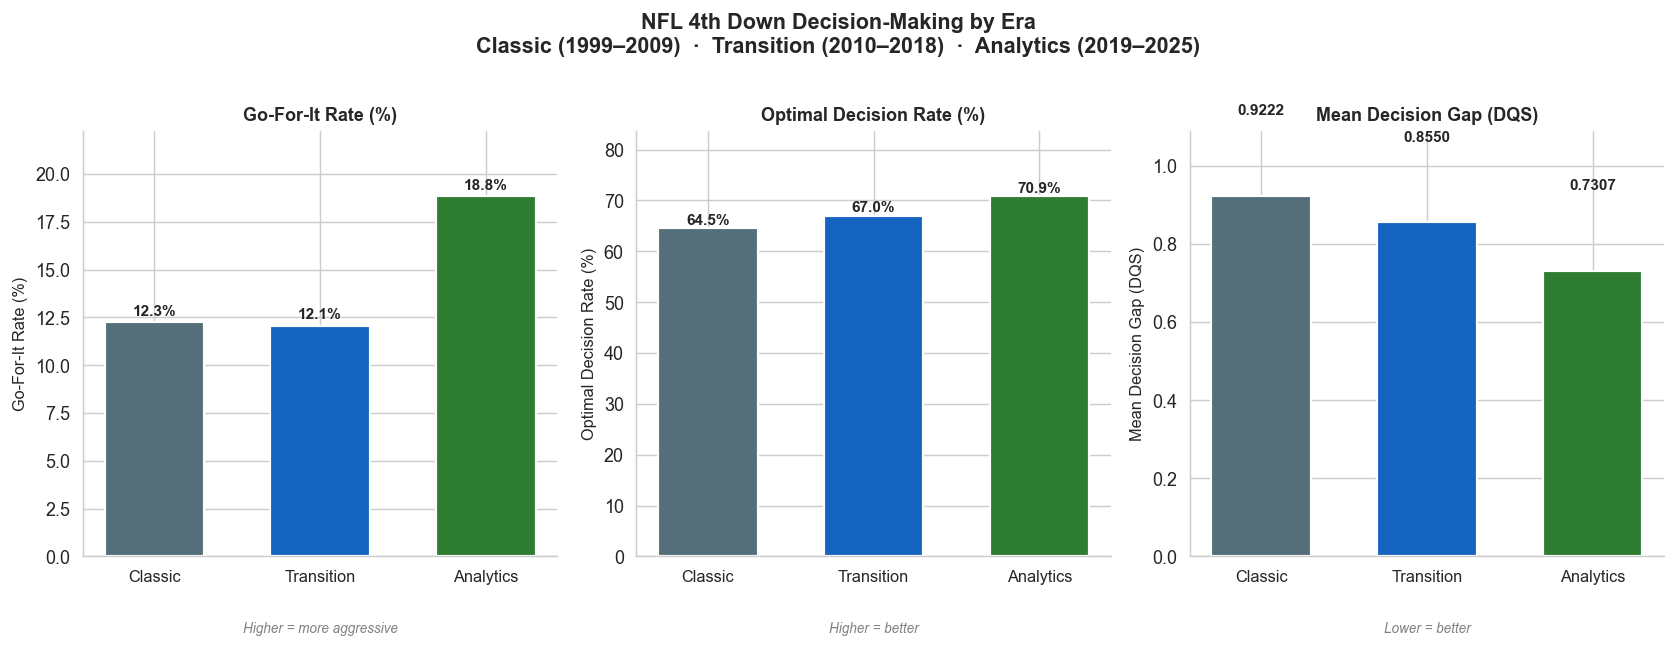

Saved: 14_era_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

eras      = era_stats['era'].tolist()
colors    = [era_label_colors[e] for e in eras]
x         = np.arange(len(eras))

metrics = [
    ('go_rate',  'Go-For-It Rate (%)',         True,  'Higher = more aggressive'),
    ('mean_odr', 'Optimal Decision Rate (%)',  True,  'Higher = better'),
    ('mean_dqs', 'Mean Decision Gap (DQS)',    False, 'Lower = better'),
]

for ax, (col, ylabel, higher_better, note) in zip(axes, metrics):
    vals = era_stats[col].values
    scale = 100 if col != 'mean_dqs' else 100
    bars = ax.bar(x, vals * scale, color=colors, edgecolor='white', linewidth=1.2, width=0.6)

    # Value labels on bars
    for bar, val in zip(bars, vals * scale):
        fmt = f'{val:.1f}%' if col != 'mean_dqs' else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002 * scale,
                fmt, ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(eras, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.text(0.5, -0.18, note, ha='center', transform=ax.transAxes,
            fontsize=7.5, color='grey', style='italic')
    ax.set_ylim(0, vals.max() * scale * 1.18)
    sns.despine(ax=ax, left=False)

fig.suptitle(
    'NFL 4th Down Decision-Making by Era\nTraditional (1999–2018)  ·  Analytics (2019–2025)',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '14_era_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: 14_era_comparison.png')

## 8. Chart — WPA Left on the Table by Season
Total `decision_gap` summed across all plays each season — how much collective WPA
is the league leaving on the table, and is that gap shrinking?

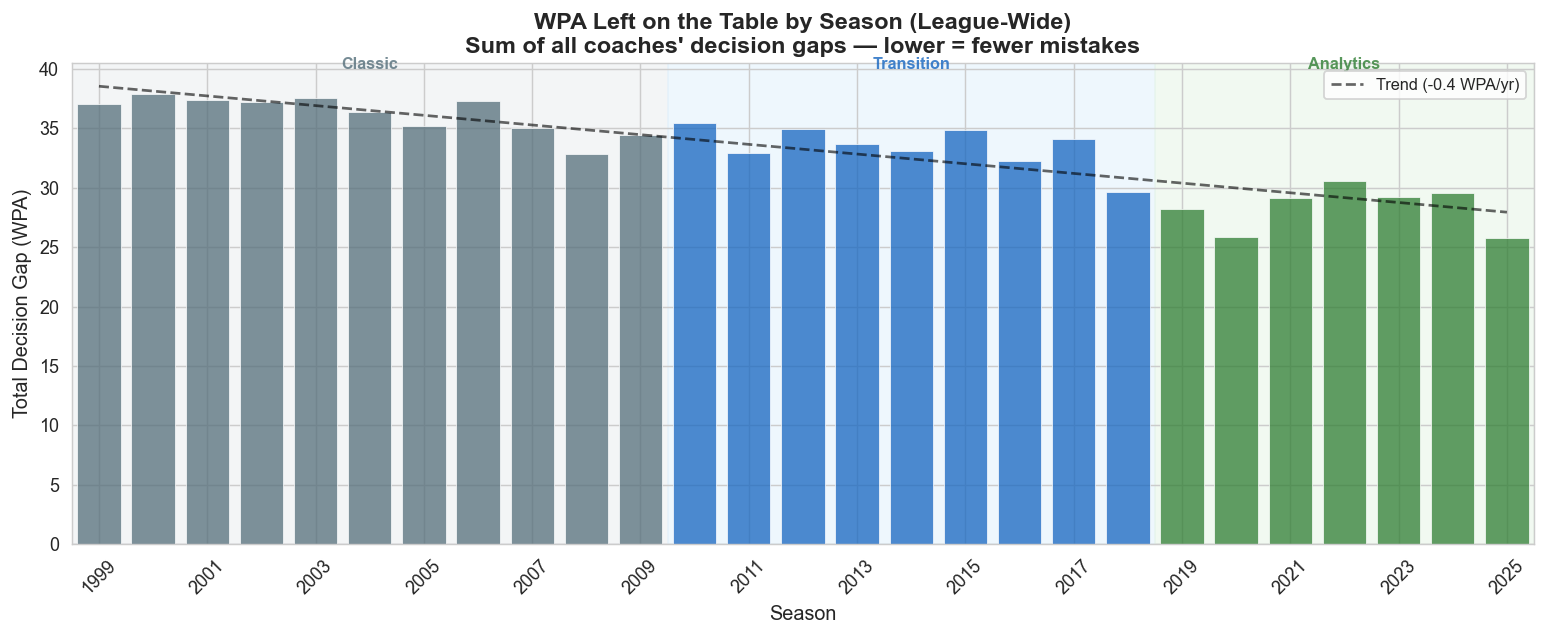

Saved: 15_wpa_left_on_table.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

# Era shading
for era_name, y_start, y_end, color in era_bg:
    ax.axvspan(y_start - 0.5, y_end + 0.5, color=color, alpha=0.6, zorder=0)
    ax.text(
        (y_start + y_end) / 2,
        by_season['total_gap'].max() * 1.05,
        era_name, ha='center', va='bottom', fontsize=9,
        color=era_label_colors[era_name], fontweight='bold', alpha=0.8
    )

# Color bars by era
bar_colors = by_season['season'].apply(
    lambda s: '#546E7A' if s <= 2018 else '#2E7D32'
)
bars = ax.bar(seasons, by_season['total_gap'], color=bar_colors, alpha=0.75,
              edgecolor='white', linewidth=0.5, zorder=2)

# Trend line
z = np.polyfit(seasons, by_season['total_gap'], 1)
p = np.poly1d(z)
ax.plot(seasons, p(seasons), color='black', linewidth=1.5,
        linestyle='--', alpha=0.6, zorder=3, label=f'Trend ({z[0]:+.1f} WPA/yr)')

ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Total Decision Gap (WPA)', fontsize=11)
ax.set_xlim(1998.5, 2025.5)
ax.set_xticks(range(1999, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.set_title(
    'WPA Left on the Table by Season (League-Wide)\nSum of all coaches\' decision gaps — lower = fewer mistakes',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '15_wpa_left_on_table.png', bbox_inches='tight')
plt.show()
print('Saved: 15_wpa_left_on_table.png')

## 9. Save league_trends.csv

In [10]:
league_trends = by_season[[
    'season', 'n_decisions', 'go_rate', 'punt_rate', 'fg_rate',
    'mean_dqs', 'mean_odr', 'total_gap'
]].copy()
league_trends['era'] = league_trends['season'].apply(era_label)

league_trends.to_csv(OUT_DIR + 'league_trends.csv', index=False)

print('Saved: outputs/league_trends.csv')
print(f'Rows: {len(league_trends)}')
print(league_trends.to_string(index=False))

Saved: outputs/league_trends.csv
Rows: 27
 season  n_decisions  go_rate  punt_rate  fg_rate  mean_dqs  mean_odr  total_gap        era
   1999         4047 0.112182   0.659007 0.228811  0.009159  0.650852  37.067761    Classic
   2000         3872 0.115961   0.661674 0.222366  0.009780  0.627583  37.869204    Classic
   2001         3945 0.115843   0.652218 0.231939  0.009483  0.633967  37.410506    Classic
   2002         3912 0.123978   0.642638 0.233384  0.009518  0.635225  37.234462    Classic
   2003         4008 0.123752   0.652944 0.223303  0.009377  0.634481  37.581024    Classic
   2004         3856 0.117739   0.670124 0.212137  0.009438  0.640820  36.394416    Classic
   2005         3995 0.118148   0.651064 0.230788  0.008803  0.657322  35.168975    Classic
   2006         3963 0.120363   0.649003 0.230633  0.009408  0.644714  37.283916    Classic
   2007         3843 0.136352   0.630237 0.233411  0.009119  0.648712  35.042413    Classic
   2008         3809 0.124967   0.6266

## 10. Summary Findings

In [11]:
traditional_go  = era_stats.loc[era_stats['era'] == 'Traditional', 'go_rate'].values[0]
analytics_go    = era_stats.loc[era_stats['era'] == 'Analytics',    'go_rate'].values[0]
traditional_dqs = era_stats.loc[era_stats['era'] == 'Traditional', 'mean_dqs'].values[0]
analytics_dqs   = era_stats.loc[era_stats['era'] == 'Analytics',   'mean_dqs'].values[0]
traditional_odr = era_stats.loc[era_stats['era'] == 'Traditional', 'mean_odr'].values[0]
analytics_odr   = era_stats.loc[era_stats['era'] == 'Analytics',   'mean_odr'].values[0]

top_adopters = team_pivot.head(5).index.tolist()
trend_slope  = np.polyfit(by_season['season'], by_season['mean_dqs'], 1)[0]
trend_dir    = 'improving (declining DQS)' if trend_slope < 0 else 'getting worse (rising DQS)'

print('=' * 60)
print('LEAGUE EVOLUTION SUMMARY')
print('=' * 60)
print(f'Go-for-it rate:   {traditional_go*100:.1f}% (Traditional) → {analytics_go*100:.1f}% (Analytics)  [{(analytics_go-traditional_go)*100:+.1f}pp]')
print(f'Mean DQS:         {traditional_dqs:.4f} (Traditional) → {analytics_dqs:.4f} (Analytics)  [{analytics_dqs-traditional_dqs:+.4f}]')
print(f'Mean ODR:         {traditional_odr*100:.1f}% (Traditional) → {analytics_odr*100:.1f}% (Analytics)  [{(analytics_odr-traditional_odr)*100:+.1f}pp]')
print()
print(f'Overall DQS trend: {trend_dir}')
print(f'Top franchise adopters: {", ".join(top_adopters)}')
print('=' * 60)

LEAGUE EVOLUTION SUMMARY
Go-for-it rate:   12.3% (Classic) → 18.8% (Analytics)  [+6.6pp]
Mean DQS:         0.0092 (Classic) → 0.0073 (Analytics)  [-0.0019]
Mean ODR:         64.5% (Classic) → 70.9% (Analytics)  [+6.4pp]

Overall DQS trend: improving (declining DQS)
Top franchise adopters: CAR, PHI, IND, CLE, NYG
